In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine import (Feed, Order, OrderLeg, Reason, CostModel, Tradelog,
                    Portfolio, Broker, StateMachineStrategy, State,
                    Transition, Context, Executing, analyzers)

# point this at your data dir (override with env BIRDSEYE_DATA for testing)
DATA_DIR = os.environ.get("BIRDSEYE_DATA", "/home/keyaan/Project/data/SPY/0-dte/train")

LOT_SIZE       = 100
TXN_PER_TRADE  = 0.85
START_CASH     = 1000000.0
LOTS           = 1        # short 1 lot of the straddle
RANGE_WIN      = 600      # trailing range window  (10 min)
DECISION_EVERY = 900     # decide every 20 min
HOLD           = 600      # square off after 10 min
RANGE_BPS_MAX  = 10.0     # short only if 10-min range < 15 bips
SESSION_LEN    = 23400    # 6.5h session in seconds (no entry within HOLD of close)

paths = sorted(glob.glob(DATA_DIR + "/*.parquet"))
print(f"{len(paths)} day(s) in {DATA_DIR}")

277 day(s) in /home/keyaan/Project/data/SPY/0-dte/train


In [ ]:
class Wait(State):
    name = "WAIT"
    transitions = {"calm_entry": "SHORT"}            # guard name -> dest
    def target(self, alphas, ctx):
        atm = ctx.get("short_atm")
        if atm is None: return None
        return ctx["strat"].close_legs([(atm,"CE"),(atm,"PE")],
                 reason=Reason(state="WAIT", note="square off"))

class Short(State):
    name = "SHORT"
    transitions = {"hold_elapsed": "WAIT"}
    def target(self, alphas, ctx):
        atm = alphas["atm"]; ctx["short_atm"] = atm
        return Order(name="short_straddle",
                     legs=[OrderLeg(atm,"CE",-LOTS),OrderLeg(atm,"PE",-LOTS)],
                     reason=Reason(state="SHORT", value=alphas["range_bps"]))
    def on_enter(self, ctx): ctx["entry_sec"] = ctx["now_sec"]

class RangeShortStraddle(StateMachineStrategy):
    states = {"WAIT": Wait(), "SHORT": Short()}
    slice_lots = 100; pause = 0; min_history = RANGE_WIN

    def __init__(self, broker):
        ctx = Context(); ctx["next_decision"]=DECISION_EVERY; ctx["short_atm"]=None
        super().__init__("WAIT", broker, name="range_short_straddle", context=ctx)
        ctx["strat"] = self

    # ---- named guards: documented, testable, Tradelog-visible ----
    def guard_calm_entry(self, a, c):
        return a["decision_now"] and a["range_bps"] < RANGE_BPS_MAX \
               and a["sec"] < SESSION_LEN - HOLD
    def guard_hold_elapsed(self, a, c):
        return a["sec"] - c["entry_sec"] >= HOLD

    def compute_alphas(self, snap):
        c = self.context; sec = snap.i
        h = snap.spot_hist(RANGE_WIN)
        rng = (h.max()-h.min())/snap.spot*1e4
        dn = sec >= c["next_decision"]
        if dn: c["next_decision"] += DECISION_EVERY
        c["now_sec"] = sec
        return {"sec":sec, "spot":snap.spot, "atm":snap.atm_strike(),
                "range_bps":rng, "decision_now":dn}

In [ ]:
def run_day(path):
    feed  = Feed.from_parquet(path)
    pf    = Portfolio(lot_size=LOT_SIZE, starting_cash=START_CASH)
    cm    = CostModel(lot_size=LOT_SIZE, txn_cost_bps=15)
    led   = Tradelog()
    br    = Broker(pf, cm, led)
    strat = RangeShortStraddle(broker=br)
    for snap in feed:
        strat.next(snap)              # FSM: alphas -> maybe fire -> EXECUTING slices
        br.mark_to_market(snap)       # per-second equity at mid
    return pf, led

from concurrent.futures import ProcessPoolExecutor
N_WORKERS = 40

results, curves, Tradelogs, day_pnls = [], {}, {}, []
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    for p, (pf, led) in zip(paths, ex.map(run_day, paths)):
        day   = os.path.basename(p).replace(".parquet", "")
        net   = pf.equity_curve[-1][1] - START_CASH
        costs = led.total_costs
        df    = led.as_dataframe()
        entries = int(((df["state"] == "SHORT") & (df["opt_type"] == "CE")).sum()) if led.fills else 0
        results.append({"day": day, "entries": entries, "gross($)": net + costs,
                        "costs($)": costs, "net($)": net})
        curves[day], Tradelogs[day] = pf.equity_curve, led
        day_pnls.append(net)

res = pd.DataFrame(results).set_index("day")
res.round(2)


pf, led = run_day(f"{DATA_DIR}/20240208.parquet")


In [16]:
led.as_dataframe()

,timestamp,strike,opt_type,lots,fill_price,txn_cost,brokerage,spread_cost,exe_cost,state,signal,value,note,strat
0,1707408001000000000,498.0,CE,-1.0,0.915,0.13725,0.0,0.5,0.63725,SHORT,calm_entry,6.039736,,
1,1707408001000000000,498.0,PE,-1.0,0.875,0.13125,0.0,0.5,0.63125,SHORT,calm_entry,6.039736,,
2,1707408601000000000,498.0,CE,1.0,0.945,0.14175,0.0,0.5,0.64175,WAIT,hold_elapsed,NaN,square off,
3,1707408601000000000,498.0,PE,1.0,0.815,0.12225,0.0,0.5,0.62225,WAIT,hold_elapsed,NaN,square off,
4,1707408901000000000,498.0,CE,-1.0,0.785,0.11775,0.0,0.5,0.61775,SHORT,calm_entry,8.434877,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,1707424801000000000,498.0,PE,1.0,0.495,0.07425,0.0,0.5,0.57425,WAIT,hold_elapsed,NaN,square off,
64,1707425101000000000,498.0,CE,-1.0,0.365,0.05475,0.0,0.5,0.55475,SHORT,calm_entry,8.233262,,
65,1707425101000000000,498.0,PE,-1.0,0.385,0.05775,0.0,0.5,0.55775,SHORT,calm_entry,8.233262,,
66,1707425701000000000,498.0,CE,1.0,0.395,0.05925,0.0,0.5,0.55925,WAIT,hold_elapsed,NaN,square off,


In [17]:
stats = analyzers.daily_stats(day_pnls)

# drawdown two ways: across the daily-PnL curve, and intraday (all seconds stitched)
all_curve = []
for day in res.index:
    all_curve += curves[day]
intraday_dd = analyzers.max_drawdown(all_curve)
daily_dd    = analyzers.max_drawdown(list(enumerate(np.cumsum(day_pnls))))

print("==== aggregate ====")
for k, v in stats.items():
    print(f"  {k:<14}: {v:.2f}" if isinstance(v, float) else f"  {k:<14}: {v}")
print(f"  intraday_maxDD: {intraday_dd:.2f}")
print(f"  daily_maxDD   : {daily_dd:.2f}")
print(f"  calmar        : {analyzers.calmar(day_pnls):.2f}  (uses daily-PnL drawdown)")
print(f"  total costs   : {sum(r['costs($)'] for r in results):.2f}")

==== aggregate ====
  n_days        : 277
  total_pnl     : -4784.01
  avg_day       : -17.27
  pct_pos_days  : 0.24
  pct_neg_days  : 0.56
  avg_win       : 10.22
  avg_loss      : -35.22
  best_day      : 31.57
  worst_day     : -168.36
  win_rate      : 0.24
  intraday_maxDD: -262.30
  daily_maxDD   : -4761.33
  calmar        : -0.91  (uses daily-PnL drawdown)
  total costs   : 6053.01


In [1]:
from engine import BirdsEye
from strategies.range_short_straddle import RangeShortStraddle

if __name__ == "__main__":
    be = BirdsEye(data_dir        = "/home/keyaan/Project/data/SPY/0-dte/train",
                  strategy_cls    = RangeShortStraddle,
                  fields          = ("bid_0","ask_0"),
                  lot_size        = 100,
                  starting_cash   = 1000000.0,
                  strategy_kwargs = {"lots": 1, "range_bps_max": 15.0},
                  n_workers       = 40)
    
    res = be.run()

=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,50,-18.5,29.0,-47.5
20240104,50,22.5,28.0,-5.5
20240105,42,39.5,25.0,14.5
20240109,46,-25.5,26.5,-52.0
20240110,54,-17.0,30.0,-47.0
...,...,...,...,...
20250804,54,53.0,29.0,24.0
20250806,46,-5.0,25.5,-30.5
20250807,30,36.5,19.0,17.5


=== aggregate stats ===
  n_days          : 277
  total_pnl       : -4779.5
  avg_day         : -17.25
  pct_pos_days    : 0.36
  pct_neg_days    : 0.58
  avg_win         : 14.36
  avg_loss        : -38.28
  best_day        : 71.0
  worst_day       : -135.0
  win_rate        : 0.36
  cagr            : -0.0
  calmar          : -0.92
  maxDD_pct       : -0.0
  churn_per_day   : 0.0
  daily_maxDD     : -4753.0
  intraday_maxDD  : -220.0
  total_costs     : 7011.5
  n_fills         : 10864


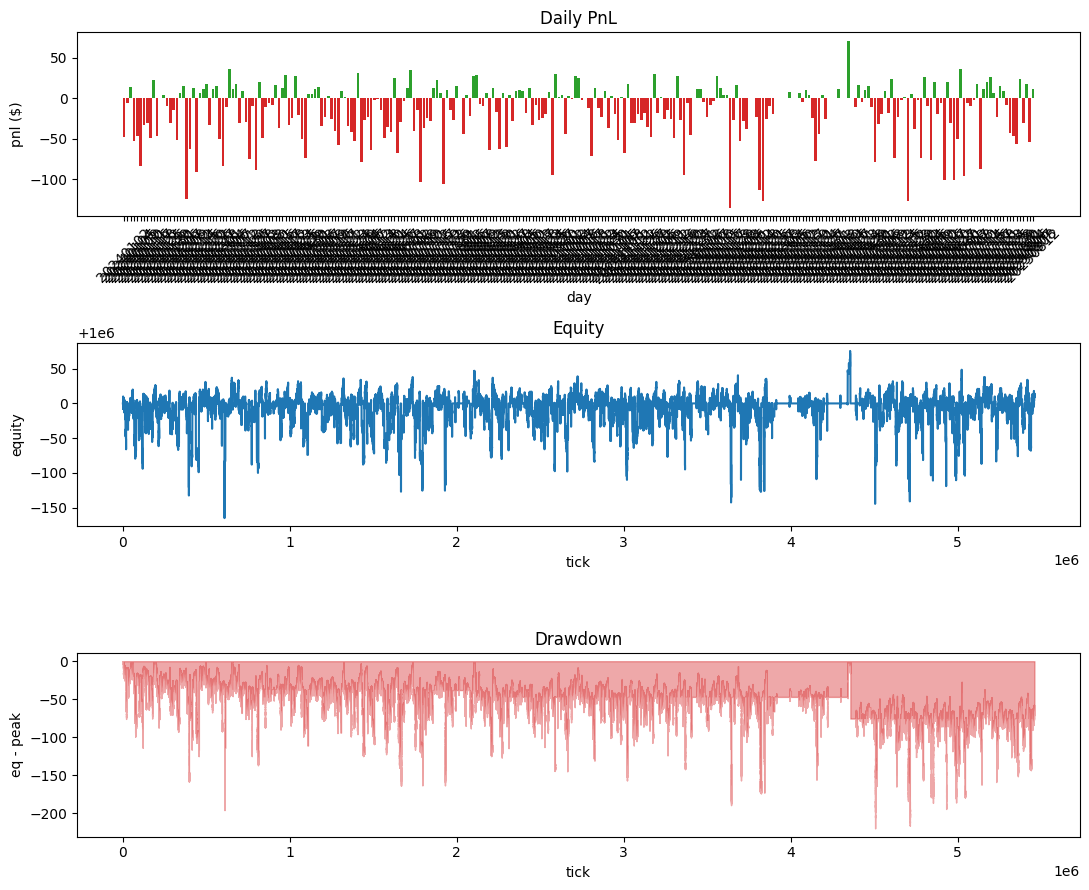

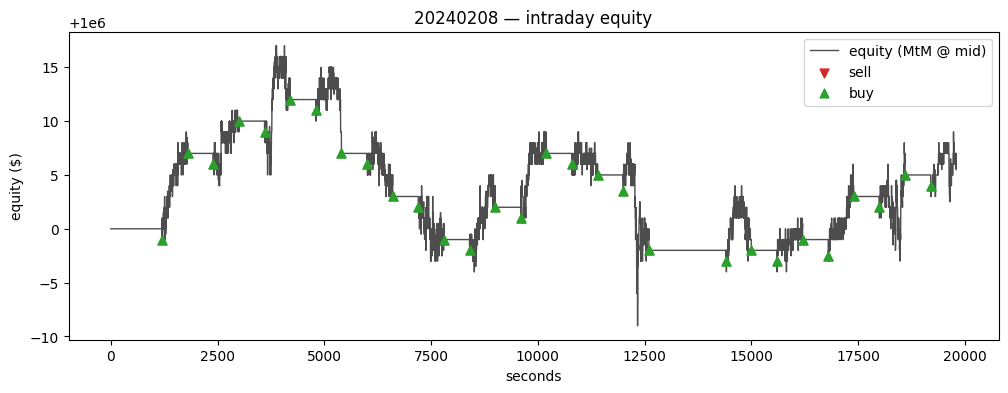

=== trade ledger: 10864 fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,exe_cost,state,signal,note,alpha_sec,alpha_spot,alpha_atm,alpha_range_bps,alpha_decision_now
0,20240102,1704210601000000000,471.0,CE,SELL,1.0,1.23,0.0,0.0,0.5,0.5,SHORT,calm_entry,,1200,471.40,471.0,14.64,1
1,20240102,1704210601000000000,471.0,PE,SELL,1.0,0.82,0.0,0.0,0.5,0.5,SHORT,calm_entry,,1200,471.40,471.0,14.64,1
2,20240102,1704211201000000000,471.0,CE,BUY,1.0,1.61,0.0,0.0,1.0,1.0,WAIT,hold_elapsed,square off,1800,472.14,472.0,18.64,0
3,20240102,1704211201000000000,471.0,PE,BUY,1.0,0.46,0.0,0.0,0.5,0.5,WAIT,hold_elapsed,square off,1800,472.14,472.0,18.64,0
4,20240102,1704211801000000000,472.0,CE,SELL,1.0,1.00,0.0,0.0,0.5,0.5,SHORT,calm_entry,,2400,472.26,472.0,14.82,1
5,20240102,1704211801000000000,472.0,PE,SELL,1.0,0.74,0.0,0.0,0.5,0.5,SHORT,calm_entry,,2400,472.26,472.0,14.82,1
6,20240102,1704212401000000000,472.0,CE,BUY,1.0,0.88,0.0,0.0,0.5,0.5,WAIT,hold_elapsed,square off,3000,472.07,472.0,10.38,0
7,20240102,1704212401000000000,472.0,PE,BUY,1.0,0.78,0.0,0.0,0.5,0.5,WAIT,hold_elapsed,square off,3000,472.07,472.0,10.38,0
8,20240102,1704214201000000000,472.0,CE,SELL,1.0,0.57,0.0,0.0,0.5,0.5,SHORT,calm_entry,,4800,471.67,472.0,12.51,1
9,20240102,1704214201000000000,472.0,PE,SELL,1.0,0.90,0.0,0.0,0.5,0.5,SHORT,calm_entry,,4800,471.67,472.0,12.51,1


fills by signal:


,count,sum
signal,,
calm_entry,5642,3267.5
hold_elapsed,5222,3744.0


=== per-second log 20240208: 19772 rows ===


,timestamp,spot,atm,state,sec,range_bps,decision_now
2000,1707408202000000000,498.17,498.0,WAIT,2002.0,7.43,False
2001,1707408203000000000,498.17,498.0,WAIT,2003.0,7.43,False
2002,1707408204000000000,498.17,498.0,WAIT,2004.0,7.43,False
2003,1707408205000000000,498.16,498.0,WAIT,2005.0,7.43,False
2004,1707408206000000000,498.15,498.0,WAIT,2006.0,7.43,False


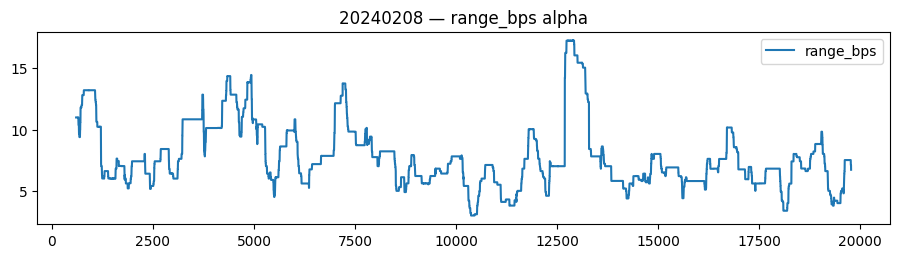

In [6]:
import matplotlib.pyplot as plt

DAY = "20240208"

# ---- 1. per-day summary table ----
print("=== per-day summary ===")
display(res.summary)

# ---- 2. aggregate stats ----
print("=== aggregate stats ===")
for k, v in res.stats().items():
    print(f"  {k:<16}: {v}")

# ---- 3. plots: daily PnL / stitched equity / drawdown ----
res.tearsheet()
plt.show()

# ---- 4. single-day deep dive: intraday MtM with buy/sell markers ----
res.plot_day(DAY)
plt.show()

# ---- 5. trade ledger (all days) ----
led = res.Tradelog()
print(f"=== trade ledger: {len(led)} fills ===")
display(led.head(10))                                  # alpha_* cols show fire-time values
print("fills by signal:"); display(led.groupby("signal")["exe_cost"].agg(["count", "sum"]).round(2))

# ---- 6. per-second log for one day ----
sl = res.perseclog(DAY)
print(f"=== per-second log {DAY}: {len(sl)} rows ===")
display(sl.iloc[2000:2005])                            # spot, atm, state, every alpha
sl.plot(y="range_bps", figsize=(11, 2.5), title=f"{DAY} — range_bps alpha")
plt.show()